In [31]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def load_results(file_path):
    """
    Load results from a pickle file.

    Args:
        file_path (str): Path to the pickle file.

    Returns:
        dict: Dictionary containing the loaded results.
    """
    try:
        with open(file_path, 'rb') as f:
            results = pickle.load(f)
        return results
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None 

In [32]:
rel_path = "/mnt/home/khain/FSNet/"
dir_path = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251010-104034_MLP_FSNet_seed0_dropout0.1_finetune_20251010-085026_model_40/results.pkl"

results = load_results(rel_path + dir_path)

In [33]:
def get_train_metrics(results):
    """
    Extract training metrics from the results dictionary.

    Args:
        results (dict): Dictionary containing training history.

    Returns:
        dict: Dictionary containing lists of training metrics.
    """
    train_metrics = {
        'obj': [],
        'loss': [],
        'eq_violation': [],
        'ineq_violation': [],
        'eq_violation_l1': [],
        'ineq_violation_l1': [],
        'distance': []    
    }

    for k in range(len(results['train_history'])):
        for key in train_metrics.keys():
            train_metrics[key].append(results['train_history'][k][key])
    
    return train_metrics

def get_val_metrics(results):
    """
    Extract validation metrics from the results dictionary.

    Args:
            results (dict): Dictionary containing validation history.

    Returns:
            dict: Dictionary containing lists of validation metrics.
    """
    val_metrics = {
            'objective': [],
            'true_objective': [],
            'opt_gap_mean': [],
            'opt_gap_std': [],
            'opt_gap_max': [],
            'opt_gap_min': [],
            'eq_violation_l2_mean': [],
            'eq_violation_l2_max': [],
            'ineq_violation_l2_mean': [],
            'ineq_violation_l2_max': [],
            'eq_violation_l1_mean': [],
            'eq_violation_l1_max': [],
            'ineq_violation_l1_mean': [],
            'ineq_violation_l1_max': [],
            'eq_violation_max_mean': [],
            'eq_violation_max_max': [],
            'ineq_violation_max_mean': [],
            'ineq_violation_max_max': [],
            'solution_distance_mean': [],
            'solution_distance_std': [],
            'solution_distance_max': []
    }

    for k in range(len(results['val_history'])):
        for key in val_metrics.keys():
            val_metrics[key].append(results['val_history'][k][key])

    return val_metrics

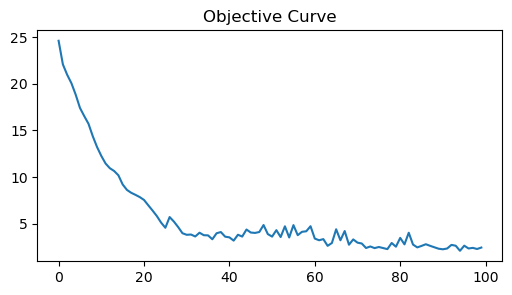

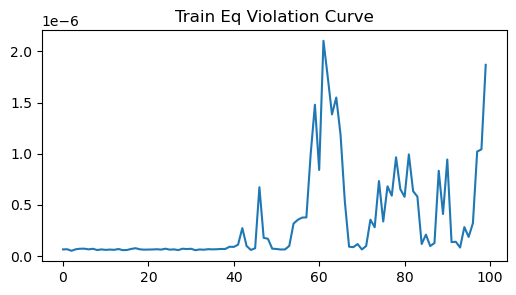

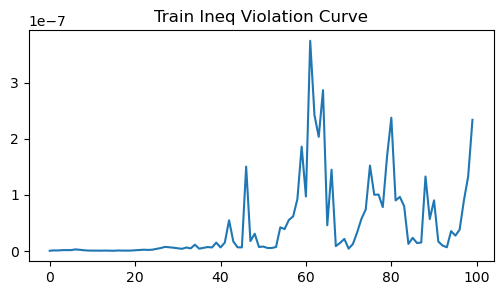

In [34]:
train_metrics = get_train_metrics(results)

start = 0
end = 200 

# plt.figure()
# plt.title('Train Loss Curve')
# plt.plot(train_metrics['loss'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Objective Curve')
plt.plot(train_metrics['obj'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Train Eq Violation Curve')
plt.plot(train_metrics['eq_violation'][start:end], label='Train Eq Violation')

plt.figure(figsize=(6, 3))
plt.title('Train Ineq Violation Curve')
plt.plot(train_metrics['ineq_violation'][start:end], label='Train Ineq Violation')

In [35]:
def get_train_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_epoch = min([len(res['train_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_epoch))
        for key in [
            'obj', 'loss',
            'eq_violation', 'ineq_violation',
            'eq_violation_l1', 'ineq_violation_l1',
            'distance'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        train_metrics = get_train_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = train_metrics[key][:num_epoch]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics

def get_val_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_evals = min([len(res['val_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_evals))
        for key in [
            'objective', 'true_objective',
            'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
            'eq_violation_l2_mean', 'eq_violation_l2_max',
            'ineq_violation_l2_mean', 'ineq_violation_l2_max',
            'eq_violation_l1_mean', 'eq_violation_l1_max',
            'ineq_violation_l1_mean', 'ineq_violation_l1_max',
            'eq_violation_max_mean', 'eq_violation_max_max',
            'ineq_violation_max_mean', 'ineq_violation_max_max',
            'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        val_metrics = get_val_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = val_metrics[key][:num_evals]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics
    

In [36]:
mean_metrics, std_metrics = get_val_metrics_stats(dir_path_seeds)
start_eval = 1
end_eval = 40
eval_range = range(start_eval, end_eval)
# mutiplie eval_range by eval_step
eval_step = 20
eval_range = [x * eval_step for x in eval_range]
for key in mean_metrics.keys():
    plt.figure()
    plt.title(f'Validation {key} Curve')
    plt.plot(eval_range, mean_metrics[key][start_eval:end_eval], label=f'Mean {key}')
    plt.fill_between(eval_range,
                     mean_metrics[key][start_eval:end_eval] - std_metrics[key][start_eval:end_eval],
                     mean_metrics[key][start_eval:end_eval] + std_metrics[key][start_eval:end_eval],
                     alpha=0.3, label=f'Std Dev {key}')
    plt.xlabel('Evaluation')
    plt.ylabel(key)
    plt.legend()
    plt.show()

NameError: name 'dir_path_seeds' is not defined

In [ ]:

# Get batch comparison data from the loaded results
batch_comparison = results['test_results']['batch_size_comparison']

# Create a more readable DataFrame by expanding the metrics
readable_data = []
for batch_size, data in batch_comparison.items():
    metrics = data['metrics']
    row = {
        'Batch Size': batch_size,
        'Opt Gap Mean (%)': f"{metrics['opt_gap_mean']:.4f}",
        'Opt Gap Std (%)': f"{metrics['opt_gap_std']*100:.4f}",
        'Opt Gap Max (%)': f"{metrics['opt_gap_max']*100:.4f}",
        'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
        'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
        'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
        'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
        'Average Batch Time (s)': f"{metrics['avg_inference_time']:.4f}",
    }
    readable_data.append(row)

df_readable = pd.DataFrame(readable_data)
df_readable_styled = df_readable.style.set_properties(**{'text-align': 'center'})
display(df_readable_styled)

,Batch Size,Opt Gap Mean (%),Opt Gap Std (%),Opt Gap Max (%),Eq Violation Mean,Eq Violation Max,Ineq Violation Mean,Ineq Violation Max,Average Batch Time (s)
0,256,-10.1516,441.3943,73.0352,2.27e+01,3.59e+01,9.41e+01,2.40e+02,0.0003
1,512,-10.0279,278.3577,118.9406,2.27e+01,3.75e+01,9.41e+01,2.50e+02,0.0003


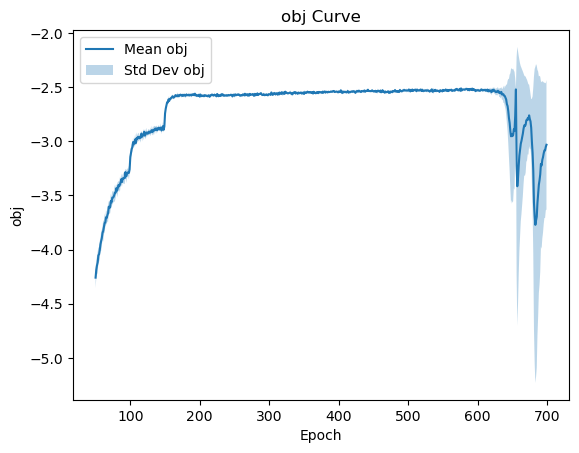

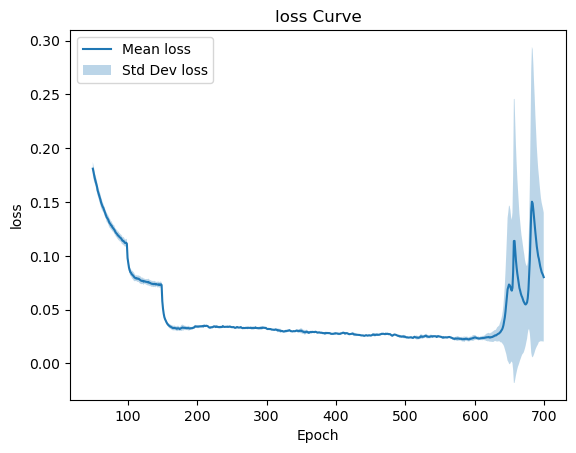

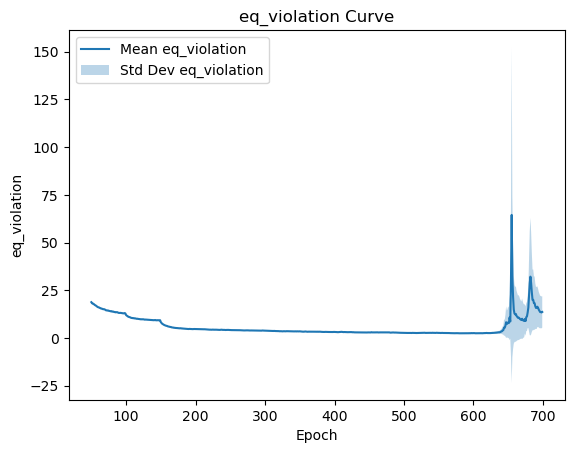

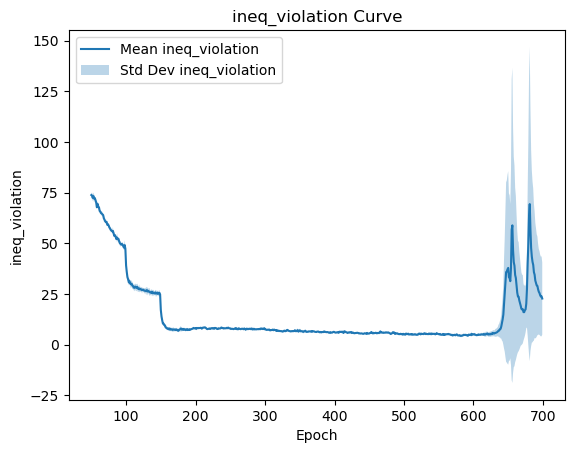

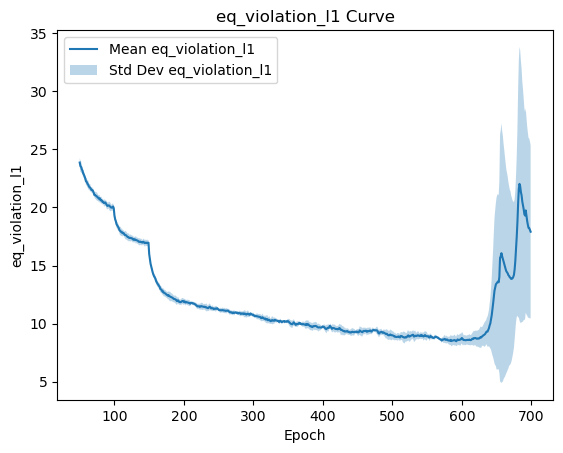

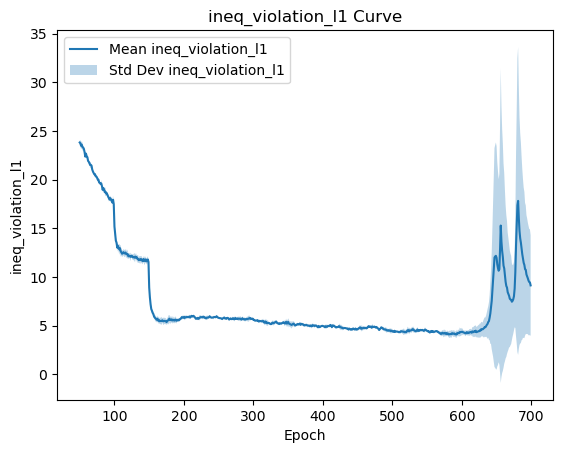

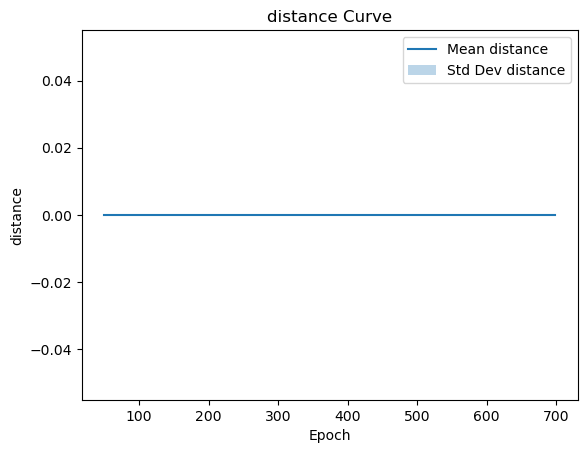

In [ ]:
# multiple seeds
dir_path_seeds = [
    "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251004-215847_MLP_sup_pen_seed1_dropout0.1/results.pkl",
    "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251004-220549_MLP_sup_pen_seed2_dropout0.1/results.pkl",
    "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251004-215146_MLP_sup_pen_seed0_dropout0.1/results.pkl"
    ]
mean_metrics, std_metrics = get_train_metrics_stats(dir_path_seeds)
start_epoch = 50
end_epoch = 700
epoch_range = range(start_epoch, end_epoch)
for key in mean_metrics.keys():
    plt.figure()
    plt.title(f'{key} Curve')
    plt.plot(epoch_range, mean_metrics[key][start_epoch:end_epoch], label=f'Mean {key}')
    plt.fill_between(epoch_range,
                     mean_metrics[key][start_epoch:end_epoch] - std_metrics[key][start_epoch:end_epoch],
                     mean_metrics[key][start_epoch:end_epoch] + std_metrics[key][start_epoch:end_epoch],
                     alpha=0.3, label=f'Std Dev {key}')
    plt.xlabel('Epoch')
    plt.ylabel(key)
    plt.legend()
    plt.show()